In [1]:
import cython
%load_ext cython

In [2]:
%%cython --compile-args=-fopenmp --link-args=-fopenmp
import numpy as np
import cython
cimport numpy as np

cimport cython
cimport openmp
ctypedef np.double_t DTYPE_t

from libc.math cimport sqrt, sin, M_PI, exp, fabs, abs, floor

from cython.parallel import prange
from libc.math cimport sqrt, fabs, fmax

from libc.math cimport sqrt, fabs

from libc.math cimport sqrt, fabs, fmax, fmin

from libc.math cimport sqrt, fabs, fmax

from libc.math cimport sqrt, fabs, fmax

from libc.math cimport sqrt, fabs, fmax, fmin


cdef inline double double_min(double a, double b) nogil: 
    return b if a >= b else a

@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline double gamma_inv(double v) nogil:
    cdef double x = 1.0 - v*v
    if x < 1e-14:
        x = 1e-14
    return sqrt(x)  # now C-level sqrt, works with nogil

@cython.boundscheck(False)
@cython.wraparound(False)

cdef inline double cmin(double a, double b, double c) nogil:
    if a <= b and a <= c:
        return a
    elif b <= a and b <= c:
        return b
    else:
        return c

@cython.boundscheck(False)
@cython.wraparound(False)

cdef inline double cmax(double a, double b, double c) nogil:
    if a >= b and a >= c:
        return a
    elif b >= a and b >= c:
        return b
    else:
        return c


################### utils for 1d fluid sims#######################################
@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void minmod_derv(double[:] u, double[:] res, int size, double theta, double dx) noexcept nogil:
    cdef int i
    cdef double e1, e2, e3
    
    for i in prange(1, size-1, nogil=True):
        e1 = theta * (u[i] - u[i-1])
        e2 = (u[i+1] - u[i-1]) / 2.0
        e3 = theta * (u[i+1] - u[i])
        if (e1 > 0 and e2 > 0 and e3 > 0):
            res[i] = cmin(e1, e2, e3) / dx
        elif (e1 < 0 and e2 < 0 and e3 < 0): 
            res[i] = cmax(e1, e2, e3) / dx
        else:
            res[i] = 0.0

    # Symmetric boundary conditions - use one-sided differences
    res[0] = theta * (u[1] - u[0]) / dx
    if res[0] * (u[2] - u[1]) < 0:  # Check sign consistency
        res[0] = 0.0
        
    res[size - 1] = theta * (u[size-1] - u[size-2]) / dx
    if res[size - 1] * (u[size-2] - u[size-3]) < 0:
        res[size - 1] = 0.0

@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void normal_derv(double[:] u, double[:] res, int size, double dx) noexcept nogil:
    """frist order derivative with forward difference"""
    cdef int i
    for i in prange(1, size -1, nogil=True):
        res[i] = (u[i+1] - u[i]) / dx
    res[size - 1] = 0

@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void normal_derv2(double[:] u, double[:] res, int size, double dx) noexcept nogil:
    """second order derivative with central difference"""
    cdef int i
    for i in prange(1, size -1, nogil=True):
        res[i] = (u[i+1] + u[i-1] - 2*u[i]) / (dx*dx)
    res[0] = 0
    res[size - 1] = 0

@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void get_up(double [:] u, double [:] ux, double [:] up, int size, double dx) noexcept nogil:
    cdef int i
    for i in prange(0,size - 1, nogil=True):
        up[i] = u[i+1] - dx * ux[i+1] / 2
    up[size-1] = up[size-2]

@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void get_um(double [:] u, double [:] ux, double [:] um, int size, double dx) noexcept nogil:
    cdef int i
    for i in prange(0,size, nogil=True):
        um[i] = u[i] + dx * ux[i] / 2


@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline double mu_ab(double a, double b) nogil:
    cdef double denom = 1 - a*b
    if fabs(denom) < 1e-14:
        denom = 1e-14  # protect division
    return fabs(a - b) / denom

cdef double AHF1 = sqrt(1.0 / 3.0)  # still fine


###### get the convection fluxes function (f1, f2, ... fn) and functions g(x, u) ######
@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void getf6(double [:] u6, double [:] p, double [:] v, double [:] f6, int size) noexcept nogil:
    cdef int i
    for i in prange(0, size, nogil=True):
        f6[i] = u6[i] * v[i] + p[i]
        #f2[i] =  v[i]**2 * (u1[i] + p[i]) + p[i]

@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void getg1(double[:] dphidr1, double[:] g1, double vw, int size) noexcept nogil:
    cdef int i
    for i in prange(0, size, nogil=True):
        g1[i] = dphidr1[i] * vw



@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void getg2(double [:] u2, double [:] v, double [:] dVdphi, double[:] g2, double eta, int size) noexcept nogil:
    cdef int i
    for i in prange(0, size, nogil=True):
        g2[i] = dVdphi[i] 

@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void getg3(double[:] dphidr2, double[:] g3, double vw, int size) noexcept nogil:
    cdef int i
    for i in prange(0, size, nogil=True):
        g3[i] = dphidr2[i] * vw

@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void getg4(double [:] u2, double [:] v, double [:] dVdphi, double[:] g4, double eta, int size) noexcept nogil:
    cdef int i
    for i in prange(0, size, nogil=True):
        g4[i] = dVdphi[i] 

@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void getg5(double [:] u6, double [:] r, double[:] dphidr1,  double [:] dVdphi1, double[:] dphidr2, double [:] dVdphi2,  double [:] g5, double vw, int size) noexcept nogil:
    cdef int i
    for i in prange(0, size, nogil=True):
        g5[i] =  2 * u6[i] / r[i] + vw *(dVdphi1[i] *dphidr1[i] +dVdphi2[i] *dphidr2[i])

# get f2
@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void getg6(double[:] u6, double[:] v, double[:] r, double[:] g6, int size) noexcept nogil:
    cdef double d = 3.0
    cdef int i
    for i in prange(0, size, nogil=True):
        g6[i] = (d - 1.0) / r[i] * (u6[i] * v[i])


###### get the dissipation fluxes fuction (Q1, Q2, ..., Qn) and functions R(x, u, ux) ######


@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void getQ2(double[:] dphidr, double[:] Q2, int size) noexcept nogil:
    cdef int i
    for i in prange(0, size, nogil=True):
        Q2[i] = dphidr[i]
    # Set boundary if needed
    #if size > 0:
        #Q2[0] = dphidr[0] if size > 0 else 0.0

@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void getQ4(double[:] dphidr, double[:] Q4, int size) noexcept nogil:
    cdef int i
    for i in prange(0, size, nogil=True):
        Q4[i] = dphidr[i]
    # Set boundary if needed
    #if size > 0:
        #Q4[0] = dphidr[0] if size > 0 else 0.0

@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void getR2(double[:] dphidr,  double [:] r, double [:] R2,  int size) noexcept nogil:
    cdef int i
    for i in prange(0, size, nogil=True) :
        R2[i] = 2 / r[i] * dphidr[i] 

@cython.boundscheck(False)
@cython.wraparound(False)
cdef inline void getR4(double[:] dphidr,  double [:] r, double [:] R4,  int size) noexcept nogil:
    cdef int i
    for i in prange(0, size, nogil=True) :
        R4[i] = 2 / r[i] * dphidr[i] 



@cython.boundscheck(False)  # Deactivate bounds checking
@cython.wraparound(False)
cdef inline void getR6(double [:] dVdphi1, double [:] dphidr1, double [:] dVdphi2, double [:] dphidr2, double [:] v, double[:] R6, double eta, int size) noexcept  nogil:
    cdef int i
    for i in prange(0, size, nogil=True):
        R6[i] = - dVdphi1[i] * dphidr1[i] - dVdphi2[i] * dphidr2[i] 

# advance u1 and u2
@cython.boundscheck(False)
@cython.wraparound(False)
cpdef rhs(double[::1] u1, double [::1] u2, double [::1] u3, double [::1] u4,double [::1] u5,double [::1] u6,
              double[::1] u1_new, double [::1] u2_new, double [::1] u3_new, double [::1] u4_new,double [::1] u5_new,double [::1] u6_new,
              double [::1] r, double dx, double cfl, int size, double theta, double eta, double vw,
              double [::1] p, double [::1] v, double [::1] dVdphi1, double [::1] dVdphi2,double[::1] Hhf5, double[::1] Hhf6,
              double[::1] PQ2,double[::1] PQ4,
              double[::1] vx, double[::1] vp, double[::1] vm,
              double[::1] px, double[::1] pp, double[::1] pm,
              double[::1] ux1, double[::1] unx1,
              double[::1] ux3, double[::1] unx3,
              double [::1] nx1, double[::1] nx3,
              double[::1] ux5, double[::1] up5, double[::1] um5,
              double[::1] ux6, double[::1] up6, double[::1] um6,
              double[::1] g1, double[::1] g2, double[::1] g3, double[::1] g4, double[::1] g5,double[::1] g6,
              double[::1] R2,double[::1] R4, double[::1] R6,
              double[::1] Q2, double[::1] Q4, double[::1] f6p, double[::1] f6m):

    cdef int i
    cdef double tmp_T, tmp_w, tmp_u1, tmp_u5, tmp_u2
      # ADD THIS BLOCK - Initialize all output arrays to zero
    for i in prange(size, nogil=True):
        u1_new[i] = 0.0
        u2_new[i] = 0.0
        u3_new[i] = 0.0
        u4_new[i] = 0.0
        u5_new[i] = 0.0
        u6_new[i] = 0.0
    # END OF ADDED BLOCK
   
    minmod_derv(v, vx,size, theta, dx)
    get_up(v, vx, vp, size, dx)
    get_um(v, vx, vm, size, dx)
    
    
    minmod_derv(p, px, size, theta, dx)
    get_up(p, px, pp, size, dx)
    get_um(p, px, pm, size, dx)

    # get us
    minmod_derv(u1, ux1, size, theta, dx)#normal_derv(u1, size, dx)
    ux1[size - 1] = 0 ##
    normal_derv2(u1, unx1, size, dx)##
    
    minmod_derv(u3, ux3, size, theta, dx)#normal_derv(u1, size, dx)
    ux3[size - 1] = 0 ##
    normal_derv2(u3, unx3, size, dx)##
    
    
    minmod_derv(u5, ux5, size, theta, dx)
    get_up(u5, ux5, up5, size, dx)
    get_um(u5, ux5, um5, size, dx)
    
    minmod_derv(u6, ux6, size, theta, dx)
    get_up(u6, ux6, up6, size, dx)
    get_um(u6, ux6, um6, size, dx)

    # get gs
    getg1(ux1, g1,  vw,  size)
    getg2(u2, v, dVdphi1, g2, eta, size)
    getg3(ux3, g3,  vw,  size)
    getg4(u2, v, dVdphi2, g4, eta, size)
   
    
    getg5(u6, r, ux1, dVdphi1, ux3, dVdphi2, g5,vw,  size)
    getg6(u6, v, r, g6, size)
    
    normal_derv(u1,  nx1, size, dx)
    normal_derv(u3,  nx3, size, dx)

    # get qs 
    getR2(nx1, r, R2, size)
    getR4(nx3, r, R4, size)
    getR6(dVdphi1, ux1, dVdphi2, ux3, v, R6, eta, size)

    getQ2(unx1, Q2, size)
    getQ4(unx3, Q4, size)
    getf6(up6, pp, vp, f6p, size)
    getf6(um6, pm, vm, f6m, size)
    
    Hhf5[0] = (up6[0] + um6[0]) / 2 - AHF1 * (up5[0] - um5[0]) / 2
    Hhf6[0] = (f6p[0] + f6m[0]) / 2 - AHF1 * (up6[0] - um6[0]) / 2
    PQ2[0] = (Q2[0] + Q2[1])/2
    PQ4[0] = (Q4[0] + Q4[1])/2
    
        # First set the values for all i >= 1
    for i in range(1, size):
        PQ2[i] = (Q2[i] + Q2[i-1])/2
        PQ4[i] = (Q4[i] + Q4[i-1])/2
        Hhf5[i] = (up6[i] + um6[i]) / 2 - AHF1 * (up5[i] - um5[i]) / 2
        Hhf6[i] = (f6p[i] + f6m[i]) / 2 - AHF1 * (up6[i] - um6[i]) / 2
        u1_new[i] = -g1[i]
        u3_new[i] = -g3[i]
        if (i < size - 1):
            u2_new[i] = PQ2[i]- g2[i] + R2[i]
            u4_new[i] = PQ4[i] - g4[i] + R4[i]
        u5_new[i] = - (Hhf5[i] - Hhf5[i-1])  / dx - g5[i] 
        u6_new[i] =  - (Hhf6[i] - Hhf6[i-1]) / dx - g6[i] + R6[i]
    
    # NOW set boundary conditions (after the loop, so u1_new[1] and u3_new[1] exist)
    u1_new[0] = 0
    u1_new[size - 1] = 0
    u3_new[0] = 0
    u3_new[size - 1] = 0
    u2_new[0] = - g2[0] + R2[0]
    u4_new[0] = - g4[0] + R4[0]
    u5_new[0] = - (Hhf5[1] - Hhf5[0])  / dx - g5[0] 
    u6_new[0] = - (Hhf6[1] - Hhf6[0]) / dx - g6[0] + R6[0]

######################################################################
######################################################################

# the effective potential of the toy model, and its derivative respect to phi
cdef inline double veff(double h, double s, double T, 
                        double lambda_h, double lambda_s, double lambda_m,
                        double c_h, double c_s, double vEW, double a, double Tc) nogil:
    """
    SM + Singlet effective potential at finite T
    V = (m_h^2/2)h^2 + (m_s^2/2)s^2 + lambda_h h^4 + lambda_s/4 s^4 + lambda_m/4 h^2 s^2
    where m_h^2 = -2 c_h (T^2 - Tc^2) etc
    """
    cdef double m_h_sq, m_s_sq
    
    # Temperature-dependent masses (simplified)
    m_h_sq =  lambda_h * (vEW*vEW - (c_h/lambda_h)*T*T)
    m_s_sq = - lambda_s * (vEW*vEW - (c_h/lambda_h)*Tc*Tc) *(lambda_h*lambda_s)**(0.5) -c_s *Tc  # placeholder
    
    return (-0.5 * m_h_sq * h*h + 
            0.5 * m_s_sq * s*s + 
            0.25*lambda_h * h*h*h*h + 
            0.25 * lambda_s * s*s*s*s + 
            0.25 * lambda_m * h*h * s*s)


cdef inline double dVdT(double h, double s, double T, 
                        double lambda_h, double lambda_s, double lambda_m,
                        double c_h, double c_s, double vEW, double a, double Tc) nogil:
    """
    dV/dT = -c_h h^2 - c_s s^2 (thermal correction derivative)
    """
    return c_h * h*h*T 


cdef inline double dVdh(double h, double s, double T, 
                        double lambda_h, double lambda_s, double lambda_m,
                        double c_h, double c_s, double vEW, double a, double Tc) nogil:
    """
    dV/dh = m_h^2 h + 4 lambda_h h^3 + (lambda_m/2) h s^2
    """
    cdef double m_h_sq
    m_h_sq = lambda_h * (vEW*vEW - (c_h/lambda_h)*T*T)
    
    return m_h_sq * h +  lambda_h * h*h*h + 0.5 * lambda_m * h * s*s


cdef inline double dVds(double h, double s, double T, 
                        double lambda_h, double lambda_s, double lambda_m,
                        double c_h, double c_s, double vEW, double a, double Tc) nogil:
    """
    dV/ds = m_s^2 s + lambda_s s^3 + (lambda_m/2) h^2 s
    """
    cdef double m_s_sq
    m_s_sq = - lambda_s * (vEW*vEW - (c_h/lambda_h)*Tc*Tc) *(lambda_h*lambda_s)**(0.5) -c_s *Tc  # placeholder
    
    return m_s_sq * s + lambda_s * s*s*s + 0.5 * lambda_m * h*h * s


cpdef inline double hsT2p(double h, double s, double T, 
                        double lambda_h, double lambda_s, double lambda_m,
                        double c_h, double c_s, double vEW, double a, double Tc) nogil:
    """
    p = a T^4 / 3 - Veff(h,s,T)
    """
    return a * T*T*T*T / 3.0 - veff(h, s, T, lambda_h, lambda_s, lambda_m, c_h, c_s, vEW,a, Tc)


cpdef inline double hsT2w(double h, double s, double T, 
                        double lambda_h, double lambda_s, double lambda_m,
                        double c_h, double c_s, double vEW, double a, double Tc) nogil:
    """
    w = 4 a T^4 / 3 - T * dV/dT
    """
    return 4.0 * a * T*T*T*T / 3.0 - T * dVdT(h, s, T, lambda_h, lambda_s, lambda_m, c_h, c_s, vEW, a, Tc)


cpdef inline double DT(double h, double s, double T, 
                        double lambda_h, double lambda_s, double lambda_m,
                        double c_h, double c_s, double vEW, double a, double Tc) nogil:
    """
    d(w)/dT helper: -dV/dT = c_h h^2 + c_s s^2
    """
    return c_h * h*h 


cpdef inline double dp_dT(double h, double s, double T, 
                        double lambda_h, double lambda_s, double lambda_m,
                        double c_h, double c_s, double vEW, double a, double Tc) nogil:
    """
    dp/dT = 4 a T^3 / 3 - dV/dT
    """
    return 4.0 * a * T*T*T / 3.0 -dVdT(h, s, T, lambda_h, lambda_s, lambda_m, c_h, c_s, vEW, a, Tc)


cpdef inline double de_dT(double h, double s, double T, 
                        double lambda_h, double lambda_s, double lambda_m,
                        double c_h, double c_s, double vEW, double a, double Tc) nogil:
    """
    de/dT = 4 a T^3 - T * d(dV/dT)/dT - dV/dT
    simplified: ~ 4 a T^3 + c_h h^2 + c_s s^2
    """
    return 4.0 * a * T*T*T / 3.0 - T*2*(c_h * h*h )


cpdef inline double dw_dT(double h, double s, double T, 
                        double lambda_h, double lambda_s, double lambda_m,
                        double c_h, double c_s, double vEW, double a, double Tc) nogil:
    """
    dw/dT = 16 a T^3 / 3 - V/T - dV/dT - T * d(dV/dT)/dT
    simplified form
    """
    cdef double V, dVdT_val
    
    V = veff(h, s, T, lambda_h, lambda_s, lambda_m, c_h, c_s, vEW,a, Tc)
    dVdT_val = dVdT(h, s, T, lambda_h, lambda_s, lambda_m, c_h, c_s, vEW, a,Tc)
    
    return 16.0 * a * T*T*T / 3.0 - dVdT_val- T* (c_h * h*h )
    
#################################################################################
# find Ts from conserved variables.
@cython.boundscheck(False)
@cython.wraparound(False)
cpdef find_Ts(double [:] ws, double [:] phi, double [:] phi2, int size, 
             double T, 
            double lambda_h, double lambda_s, double lambda_m,
            double c_h, double c_s, double vEW, double a,
            double LO, double HI,double Tc, double dx, int n_iter):

    cdef double [:] Ts = np.zeros(size, dtype=np.double)
    cdef double mid, lo, hi, tmp
    cdef int i, j
    cdef double [:] dVdphis1 = np.zeros(size, dtype=np.double)
    cdef double [:] dVdphis2 = np.zeros(size, dtype=np.double)
    cdef double [:] Ps = np.zeros(size, dtype=np.double)
    #for i in prange(size, nogil=True):
    for i in range(size):
        lo = LO
        hi = HI

        for j in range(n_iter):
            mid = (hi + lo) / 2
            tmp = ws[i] - hsT2w(phi[i],  phi2[i], mid, lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a,Tc)
            if(tmp < 0):
                hi = mid
            else:
                lo = mid
            Ts[i] = mid
            dVdphis1[i] = dVdh(phi[i],  phi2[i], mid, lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a,Tc)
            dVdphis2[i] = dVds(phi[i],  phi2[i], mid, lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a,Tc)
            Ps[i] =hsT2p(phi[i],  phi2[i], mid, lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a,Tc)

    return Ts, dVdphis1, dVdphis2, Ps

@cython.boundscheck(False)
@cython.wraparound(False)

cdef inline double find_T_fm_u(double u1, double u3, double u5, double u6,
                        double lambda_h, double lambda_s, double lambda_m,
                        double c_h, double c_s, double vEW, double a,
                        double Ti,double Tc, int n_iter,
                        double tol=1e-6) nogil:
    cdef double T0, T1, T2, f0, f1, p, w
    cdef double err
    T0 = Ti
    T1 = Ti + 0.01
    T2 = T1
    w = hsT2w(u1,  u3, T0, lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a,Tc)
    p = hsT2p(u1,  u3, T0, lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a, Tc)
    
    disc = w*w + 4*u6*u6
    if disc < 1e-14:
       disc = 1e-14

    f0 = u5 + p - (w + sqrt(disc))/ 2

    while(n_iter > 0 and fabs(f0) > tol):
        
        w = hsT2w(u1,  u3, T1, lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a,Tc)
        p = hsT2p(u1,  u3, T1, lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a, Tc)

        disc = w*w + 4*u6*u6
        if disc < 1e-14:
           disc = 1e-14

        f1 = u5 + p - (w + sqrt(disc))/ 2
        
        if(fabs(f1 -f0) < 1e-8):
            break
        T2 = (T0 * f1 - T1 * f0) / (f1 - f0)
        
        f0 = f1
        T0 = T1
        
        w = hsT2w(u1,  u3, T2, lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a, Tc)
        p = hsT2p(u1,  u3, T2, lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a, Tc)

        disc = w*w + 4*u6*u6
        if disc < 1e-14:
           disc = 1e-14
        
        f1 = u5 + p - (w + sqrt(disc))/ 2
        T1 = T2
        
        n_iter -= 1
        
    if(fabs(f0) > tol):
        return -1
    if T2 < 1e-6:
       T2 = 1e-6
    if T2 > 100:
       T2 = 100
    
    return T2
  

@cython.boundscheck(False)  
@cython.wraparound(False) 
cpdef wp_restore(double [:] u1, double [:] u3, double [:] u5, double [:] u6, double [:] Ts_i,double Tc,
                        double lambda_h, double lambda_s, double lambda_m,
                        double c_h, double c_s, double vEW, double a, double dx):
        
    cdef int size = len(u1)
    
    cdef double [:] w = np.zeros(size, dtype=np.double)
    cdef double [:] p = np.zeros(size, dtype=np.double)
    cdef double [:] v = np.zeros(size, dtype=np.double)
    cdef double [:] Ts = np.zeros(size, dtype=np.double)
    cdef double [:] dVdphis1 = np.zeros(size, dtype=np.double)
    cdef double [:] dVdphis2 = np.zeros(size, dtype=np.double)
    
    cdef int idx
    cdef double w_calc, w_min, v_calc, v_max
    cdef double p_min, T_min
    cdef double denom 
    cdef double vmax 
    
    # PHYSICAL BOUNDS
    w_min = 1.0  # Minimum enthalpy (tune based on your physics)
    v_max = 0.99  # Maximum velocity (slightly below 1 for safety)
    p_min = 0.0   # Minimum pressure
    T_min = 1e-6  # Minimum temperature
    
    for idx in range(size):
        # Find temperature (with bounds on initial guess)
        Ts[idx] = find_T_fm_u(u1[idx], u3[idx], u5[idx], u6[idx], 
                lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a,
                Ts_i[idx], Tc, 40)

        if Ts[idx] == -1 or Ts[idx] != Ts[idx] or Ts[idx] <= 0:
            # Use initial guess or default, not the failed value
            if Ts_i[idx] > 0 and Ts_i[idx] == Ts_i[idx]:
                Ts[idx] = Ts_i[idx]
            else:
                Ts[idx] = 80.0  # Default temperature

        # Calculate thermodynamic quantities
        dVdphis1[idx] = dVdh(u1[idx], u3[idx], Ts[idx], lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a, Tc)
        dVdphis2[idx] = dVds(u1[idx], u3[idx], Ts[idx], lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW, a, Tc)
        
        w_calc = hsT2w(u1[idx], u3[idx], Ts[idx], lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a, Tc)
        p_calc = hsT2p(u1[idx], u3[idx], Ts[idx], lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a, Tc)
        
        # CRITICAL: Enforce physical bounds on w and p
        #if w_calc < w_min:
            #w_calc = w_min
        #if p_calc < p_min:
            #p_calc = p_min
            
        w[idx] = w_calc
        p[idx] = p_calc
                # Safe velocity calculation
        denom = u5[idx] + p[idx]
        if denom <= 0:
            denom = 1e-16
        v[idx] = u6[idx] / denom
        
        vmax = 0.995   # safety margin from light speed

        if v[idx] >= vmax:
            v[idx] = vmax
        elif v[idx] <= -vmax:
            v[idx] = -vmax

        # Optional smooth saturation (better for RK stability)
        if fabs(v[idx]) > vmax:
           v[idx] = vmax * (v[idx] / fabs(v[idx]))
        
        # CRITICAL: Safe velocity calculation with bounds
        # w = u3 + p, but u3 might be corrupted, so use our bounded w
         # compute velocity safely
        #den = u5[idx] + p[idx]
        #if fabs(den) < 1e-12:
            #den = 1e-12
        #v [idx] = u6[idx] / den
        # clamp velocity to avoid superluminal
        #v2 = v[idx] 
        #if v2 >= 0.999999:
                #factor = sqrt(0.999999 / v2)
                #v2 *= factor
    
            
        #v[idx] = v2
        
        # Optional: Adjust u3 to be consistent with bounded w and p
        # This prevents corruption in next RK stage
        # u3[idx] = w[idx] - p[idx]  # Uncomment if u3 is passed by reference
        

    return w, p, v, Ts, dVdphis1, dVdphis2

In [3]:
import sys
import numpy as np
import scipy

class scalarAfluid1d_toy:

    def __init__(self, r_in, u1_in, u2_in, u3_in, u4_in, u5_in, u6_in, theta, cfl_in, w_in, v_in, wn_in, phi1_in, phi2_in,
                  lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a, To, Tc, eta,vw, n_iter=40):
        # main parameters that need initialization:
        # u1:
        # u2:
    
        self.rhs = rhs
        self.r = r_in
        self.n_iter = n_iter

        self.u1 = u1_in
        self.u2 = u2_in
        self.u3 = u3_in
        self.u4 = u4_in
        self.u5 = u5_in
        self.u6 = u6_in
        self.phi1 = phi1_in
        self.phi2 = phi2_in
        self.lambda_h =lambda_h
        self.lambda_s =lambda_s
        self.lambda_m =lambda_m
        self.c_h = c_h
        self.c_s =c_s
        self.vEW=vEW
        self.a =a
        self.To =To
       
        self.Tc = Tc
        self.a = a
        self.eta = eta
        self.vw = vw

        self.dr = r_in[1] - r_in[0]
        self.theta = theta
        self.cfl = cfl_in
        self.dt = cfl_in * self.dr
        
        self.d = 3
        self.size = self.u1.shape[0]
        
        self.wn = wn_in
        self.w = w_in.copy()
        # self.rw = rw
        
        
        # self.T, self.cs, self.p = self.sp.w_to_pandcs(w_in, self.rw, self.dr)

        self.T, self.dVdphi1, self.dVdphi2, self.p = self.w_to_panddVdphi(self.w, self.phi1, self.phi2)
        # self.cs = self.sp.w_to_cs(w_in)
        #self.cs.fill(self.cs.mean())
        
        # self.p = self.sp.w_to_p(w_in)
        self.v = v_in.copy()
        # self.T = self.sp.find_T(w_in)
        self.Hhf5 = np.zeros(self.size, dtype=np.double)
        self.Hhf6 = np.zeros(self.size, dtype=np.double)
        self.PQ2  = np.zeros(self.size, dtype=np.double)
        self.PQ4  = np.zeros(self.size, dtype=np.double)

        self.vx = np.zeros(self.size, dtype=np.double)
        self.vp = np.zeros(self.size, dtype=np.double)
        self.vm = np.zeros(self.size, dtype=np.double)

        self.px = np.zeros(self.size, dtype=np.double)
        self.pp = np.zeros(self.size, dtype=np.double)
        self.pm = np.zeros(self.size, dtype=np.double)
        self.ux1  = np.zeros(self.size, dtype=np.double)
        self.unx1 = np.zeros(self.size, dtype=np.double)
        self.ux3  = np.zeros(self.size, dtype=np.double)
        self.unx3 = np.zeros(self.size, dtype=np.double)

        self.nx1 = np.zeros(self.size, dtype=np.double)
        self.nx3 = np.zeros(self.size, dtype=np.double)

        self.ux5 = np.zeros(self.size, dtype=np.double)
        self.up5 = np.zeros(self.size, dtype=np.double)
        self.um5 = np.zeros(self.size, dtype=np.double)

        self.ux6 = np.zeros(self.size, dtype=np.double)
        self.up6 = np.zeros(self.size, dtype=np.double)
        self.um6 = np.zeros(self.size, dtype=np.double)
      
        self.g1 = np.zeros(self.size, dtype=np.double)
        self.g2 = np.zeros(self.size, dtype=np.double)
        self.g3 = np.zeros(self.size, dtype=np.double)
        self.g4 = np.zeros(self.size, dtype=np.double)
        self.g5 = np.zeros(self.size, dtype=np.double)
        self.g6 = np.zeros(self.size, dtype=np.double)

        self.R2 = np.zeros(self.size, dtype=np.double)
        self.R4 = np.zeros(self.size, dtype=np.double)
        self.R6 = np.zeros(self.size, dtype=np.double)

        self.Q2  = np.zeros(self.size, dtype=np.double)
        self.Q4  = np.zeros(self.size, dtype=np.double)
        self.f6p = np.zeros(self.size, dtype=np.double)
        self.f6m = np.zeros(self.size, dtype=np.double)
        
        # Other parameters derived from u1 and u2
        # f1 and f2
        # g1 and g2
        #self.f1 =  u2_in
        #self.f2 = getf2(self.u1, self.u2, self.size)

        #self.g1 = getg1(self.u2, self.r, self.d, self.size)
        #self.g2 = getg2(self.u1, self.u2, self.r, self.d, self.size)

        #self.v = getv(self.u1, self.u2, self.size)

        self.u1k1 = np.zeros(self.size, dtype=np.double) 
        self.u2k1 = np.zeros(self.size, dtype=np.double) 
        self.u3k1 = np.zeros(self.size, dtype=np.double)
        self.u4k1 = np.zeros(self.size, dtype=np.double)
        self.u5k1 = np.zeros(self.size, dtype=np.double)
        self.u6k1 = np.zeros(self.size, dtype=np.double)

        self.u1k2 = np.zeros(self.size, dtype=np.double) 
        self.u2k2 = np.zeros(self.size, dtype=np.double)
        self.u3k2 = np.zeros(self.size, dtype=np.double)
        self.u4k2 = np.zeros(self.size, dtype=np.double)
        self.u5k2 = np.zeros(self.size, dtype=np.double)
        self.u6k2 = np.zeros(self.size, dtype=np.double)

        self.u1k3 = np.zeros(self.size, dtype=np.double) 
        self.u2k3 = np.zeros(self.size, dtype=np.double)
        self.u3k3 = np.zeros(self.size, dtype=np.double)
        self.u4k3 = np.zeros(self.size, dtype=np.double)
        self.u5k3 = np.zeros(self.size, dtype=np.double)
        self.u6k3 = np.zeros(self.size, dtype=np.double)

        self.u1k4 = np.zeros(self.size, dtype=np.double) 
        self.u2k4 = np.zeros(self.size, dtype=np.double)
        self.u3k4 = np.zeros(self.size, dtype=np.double)
        self.u4k4 = np.zeros(self.size, dtype=np.double)  
        self.u5k4 = np.zeros(self.size, dtype=np.double) 
        self.u6k4 = np.zeros(self.size, dtype=np.double) 
        self.res = np.zeros(self.size, dtype=np.double) 

        print(f"INIT: u1 range: [{np.min(self.u1):.6e}, {np.max(self.u1):.6e}]")
        print(f"INIT: u5 range: [{np.min(self.u5):.6e}, {np.max(self.u5):.6e}]")
        print(f"INIT: w range: [{np.min(self.w):.6e}, {np.max(self.w):.6e}]")
        print(f"INIT: p range: [{np.min(self.p):.6e}, {np.max(self.p):.6e}]")
        print(f"INIT: T range: [{np.min(self.T):.6e}, {np.max(self.T):.6e}]")

    def find_T(self, ws, phis1, phis2):
        if(type(ws) == np.ndarray and type(phis1) == np.ndarray and type(phis2) == np.ndarray):
            Ts, dVdphi1, dVdphi2, Ps = find_Ts(ws, phis1, phis2, ws.shape[0], self.To,
                                  self.lambda_h,self.lambda_s, self.lambda_m,self.c_h,  self.c_s,  self.vEW,self.a,
                                  self.To, self.Tc, self.Tc,self.dr, self.n_iter) 
            Ts = np.array(Ts)
            dVdphi1 = np.array(dVdphi1)
            dVdphi2 = np.array(dVdphi2)
            Ps = np.array(Ps)
            #Ts = savgol_filter(Ts, 21, 3, mode='nearest')
            return Ts, dVdphi1, dVdphi2, Ps
        else:
            raise NotImplementedError("Only support array input for ws and phis")
    
    def w_to_panddVdphi(self, ws, phis1, phis2):
        Ts, dVdphi1, dVdphi2, Ps= self.find_T(ws, phis1, phis2)
        return Ts, dVdphi1, dVdphi2, Ps

    def wp_restore(self, u1, u2, u3, u4, u5, u6, Ts_i, dx):
        w, p, v, T, dVdphi1,dVdphi2 = wp_restore(u1, u3, u5, u6, Ts_i, self.Tc,self.lambda_h, self.lambda_s,  self.lambda_m,self.c_h,  self.c_s,  self.vEW,self.a, dx)
        #size = len(u1)
        #for idx in range(min(5, size)):  # Only check first 5 points
          #print(f"\n=== idx={idx} ===")
          #print(f"u1={u1[idx]:.6e}, u3={u3[idx]:.6e}")
          #print(f"u5={u5[idx]:.6e}, u6={u6[idx]:.6e}")
         
          #T_test_vals = np.logspace(-2, 3, 50)  # 0.01 to 1000
          ##residuals = []
          #for T_test in T_test_vals:
            # w = phiaT2w(u1[idx], T_test,self.gamma,self.delta,self.labda,self.To, u3[idx],self.gamma2,self.delta2,self.labda2,self.To2,self.a)  # You need to expose this
             #p = phiaT2p(u1[idx], T_test,self.gamma,self.delta,self.labda,self.To, u3[idx],self.gamma2,self.delta2,self.labda2,self.To2,self.k,self.a)
             #res[idx] = u5[idx] + p - (w + np.sqrt(w*w + 4*u6[idx]*u6[idx]))/2
             #residuals.append(res)
             #if idx == 0:
                #print(f"  T={T_test:.3e}: w={w:.3e}, p={p:.3e}, res={res:.3e}")
        
        # Check if residual changes sign (indicates root exists)
        #residuals = np.array(residuals)
        #if np.any(residuals[:-1] * residuals[1:] < 0):
            #print(f"  ROOT EXISTS in range")
        #else:
            #print(f"  NO ROOT FOUND - check your conserved variables!")
            #print(f"  Residual range: [{np.min(residuals):.3e}, {np.max(residuals):.3e}]")
        return np.array(w), np.array(p), np.array(v), np.array(T), np.array(dVdphi1), np.array(dVdphi2)
        
    def advance_rk4(self, dt):
        alpha = 0.7   # damping factor
        # ADD THIS
        #print(f"DEBUG: Before RK4 - u1 max: {np.max(self.u1):.6e}, u5 max: {np.max(self.u5):.6e}")
        #print(np.max(np.abs(self.u1)), np.max(np.abs(self.u3)),np.max(np.abs(self.u5)),np.max(np.abs(self.u6)))
        # END ADD
        self.rhs(self.u1, self.u2, self.u3, self.u4,self.u5, self.u6,
                self.u1k1, self.u2k1, self.u3k1, self.u4k1, self.u5k1, self.u6k1, self.r, self.dr, 
                self.cfl, self.size, self.theta, self.eta, self.vw, self.p, self.v, self.dVdphi1,self.dVdphi2,
                self.Hhf5, self.Hhf6, 
                self.PQ2,self.PQ4,
                self.vx, self.vp, self.vm,
                self.px, self.pp, self.pm,
                self.ux1, self.unx1,
                self.ux3, self.unx3,
                self.nx1,self.nx3,
                self.ux5, self.up5, self.um5,
                self.ux6, self.up6, self.um6,
                self.g1, self.g2,self.g3, self.g4, self.g5,self.g6,
                self.R2,self.R4, self.R6,
                self.Q2,self.Q4, self.f6p, self.f6m)
        
        tmp_w, tmp_p, tmp_v, tmp_T, tmp_dVdphi1, tmp_dVdphi2 = self.get_wpv(self.u1 + dt / 2 * self.u1k1, self.u2 + dt / 2 * self.u2k1, 
                                                              self.u3 + dt / 2 * self.u3k1, self.u4 + dt / 2 * self.u4k1, self.u5 + dt / 2 * self.u5k1, self.u6 + dt / 2 * self.u6k1);

        self.rhs(self.u1 + dt / 2 * self.u1k1, self.u2 + dt / 2 * self.u2k1,  
                 self.u3 + dt / 2 * self.u3k1, self.u4 + dt / 2 * self.u4k1, self.u5 + dt / 2 * self.u5k1, self.u6 + dt / 2 * self.u6k1,
                 self.u1k2, self.u2k2, self.u3k2, self.u4k2, self.u5k2, self.u6k2, self.r, self.dr, 
                 self.cfl, self.size, self.theta, self.eta,self.vw, tmp_p, tmp_v, tmp_dVdphi1,tmp_dVdphi2,
                 self.Hhf5, self.Hhf6, self.PQ2,self.PQ4,
                 self.vx, self.vp, self.vm,
                 self.px, self.pp, self.pm,
                 self.ux1, self.unx1,
                 self.ux3, self.unx3,
                 self.nx1,self.nx3,
                 self.ux5, self.up5, self.um5,
                 self.ux6, self.up6, self.um6,
                 self.g1, self.g2,self.g3, self.g4, self.g5,self.g6,
                 self.R2,self.R4, self.R6,
                 self.Q2,self.Q4, self.f6p, self.f6m)
        
        tmp_w, tmp_p, tmp_v, tmp_T,tmp_dVdphi1,tmp_dVdphi2 =self.get_wpv(self.u1 + dt / 2 *self.u1k2,self.u2 + dt / 2 *self.u2k2,
                                                                         self.u3 + dt / 2 *self.u3k2,self.u4 + dt / 2 *self.u4k2,
                                                                         self.u5 + dt / 2 *self.u5k2,self.u6 + dt / 2 *self.u6k2)


        self.rhs(self.u1 + dt / 2 * self.u1k2, self.u2 + dt / 2 * self.u2k2,  
                 self.u3 + dt / 2 * self.u3k2, self.u4 + dt / 2 * self.u4k2, self.u5 + dt / 2 * self.u5k2, self.u6 + dt / 2 * self.u6k2,
                 self.u1k3, self.u2k3, self.u3k3, self.u4k3, self.u5k3, self.u6k3, self.r, self.dr, 
                 self.cfl, self.size, self.theta, self.eta, self.vw,tmp_p, tmp_v, tmp_dVdphi1,tmp_dVdphi2,
                 self.Hhf5, self.Hhf6, self.PQ2,self.PQ4,
                 self.vx, self.vp, self.vm,
                 self.px, self.pp, self.pm,
                 self.ux1, self.unx1,
                 self.ux3, self.unx3,
                 self.nx1,self.nx3,
                 self.ux5, self.up5, self.um5,
                 self.ux6, self.up6, self.um6,
                 self.g1, self.g2,self.g3, self.g4, self.g5,self.g6,
                 self.R2,self.R4, self.R6,
                 self.Q2,self.Q4, self.f6p, self.f6m)
        
        tmp_w, tmp_p, tmp_v, tmp_T, tmp_dVdphi1, tmp_dVdphi2 = self.get_wpv(self.u1 + dt * self.u1k3, self.u2 + dt * self.u2k3, 
                                                              self.u3 + dt * self.u3k3, self.u4 + dt * self.u4k3,self.u5 + dt * self.u5k3,self.u6 + dt * self.u6k3);
        self.rhs(self.u1 + dt * self.u1k3, self.u2 + dt * self.u2k3, 
                 self.u3 + dt * self.u3k3, self.u4 + dt * self.u4k3, self.u5 + dt * self.u5k3, self.u6 + dt * self.u6k3,
                 self.u1k4, self.u2k4, self.u3k4, self.u4k4, self.u5k4, self.u6k4, self.r, self.dr, 
                 self.cfl, self.size, self.theta, self.eta, self.vw, tmp_p, tmp_v, tmp_dVdphi1,tmp_dVdphi2,self.Hhf5, self.Hhf6, self.PQ2,self.PQ4,
                 self.vx, self.vp, self.vm,
                 self.px, self.pp, self.pm,
                 self.ux1, self.unx1,
                 self.ux3, self.unx3,
                 self.nx1,self.nx3,
                 self.ux5, self.up5, self.um5,
                 self.ux6, self.up6, self.um6,
                 self.g1, self.g2,self.g3, self.g4, self.g5,self.g6,
                 self.R2,self.R4, self.R6,
                 self.Q2,self.Q4, self.f6p, self.f6m)
        
        
        self.u1 = self.u1 + alpha * dt / 6 * (self.u1k1 + 2 * self.u1k2 + 2 * self.u1k3 + self.u1k4) 
        self.u2 = self.u2 + alpha * dt / 6 * (self.u2k1 + 2 * self.u2k2 + 2 * self.u2k3 + self.u2k4) 
        self.u3 = self.u3 + alpha * dt / 6 * (self.u3k1 + 2 * self.u3k2 + 2 * self.u3k3 + self.u3k4)
        self.u4 = self.u4 + alpha * dt / 6 * (self.u4k1 + 2 * self.u4k2 + 2 * self.u4k3 + self.u4k4)
        self.u5 = self.u5 + alpha * dt / 6 * (self.u5k1 + 2 * self.u5k2 + 2 * self.u5k3 + self.u5k4)
        self.u6 = self.u6 + alpha * dt / 6 * (self.u6k1 + 2 * self.u6k2 + 2 * self.u6k3 + self.u6k4)
         # ADD THIS
        #print(f"DEBUG: After RK4 - u1 max: {np.max(self.u1):.6e}, u3 max: {np.max(self.u3):.6e}, u5 max: {np.max(self.u5):.6e}")
        #print(f"DEBUG: k1 max: {np.max(np.abs(self.u1k1)):.6e}, k2 max: {np.max(np.abs(self.u1k2)):.6e}")
        # END ADD
        
        self.update_wpv()
    
    
    def run_step(self, n_steps, dt):

        for step in range(n_steps):
            # Performing rk4
            self.advance_rk4(dt)

    def get_wpv(self, u1, u2, u3, u4, u5, u6):
        tmp_w, tmp_p, tmp_v, tmp_T, tmp_dVdphi1,tmp_dVdphi2 = self.wp_restore(u1, u2, u3, u4, u5, u6, self.T, self.dr)
        return tmp_w, tmp_p, tmp_v, tmp_T, tmp_dVdphi1,tmp_dVdphi2
    
    def update_wpv(self):
        self.w, self.p, self.v, self.T, self.dVdphi1,self.dVdphi2= self.wp_restore(self.u1, self.u2, self.u3, self.u4,self.u5,self.u6, self.T, self.dr)
        return 

In [4]:
import numpy as np

vEW = 246.22      # GeV, electroweak VEV
Mh = 125.1        # GeV, Higgs mass
Mw = 80.385       # GeV, W boson mass
Mz = 91.1876      # GeV, Z boson mass
Mt = 173.34       # GeV, top quark mass
lambda_m =1.5 
lambda_s =0.65

# Derived couplings
g = (2.0 * Mw) / vEW                    # SU(2)_L gauge coupling ≈ 0.653
gPrime = np.sqrt((4.0*(Mz**2 - Mw**2))/(vEW**2))  # U(1)_Y gauge coupling ≈ 0.358
h_t = (np.sqrt(2) * Mt) / vEW              # top Yukawa ≈ 0.996
lambda_h = (Mh**2) / (2.0 * vEW**2)     # Higgs quartic ≈ 0.129
# For T = 80 GeV, Tc = 100 GeV (your values)
Tn = 80.0          # Nucleation temperature (GeV)
Tc = 100.0        # Critical temperature (GeV)
a = 11

# Thermal correction coefficients
c_h = (1.0/48.0) * (9*g**2 + 3*gPrime**2 + 2*(6*h_t**2 + 12*lambda_h + lambda_m))  # ≈ 0.162
c_s = (1.0/12.0) * (2*lambda_m + 3*lambda_s)  # depends on lambda_m, lambda_s below

# Radiation constant (relativistic degrees of freedom)
# g* ≈ 106.75 (SM) + singlet contributions
a = (np.pi**2 / 90) * 106.75   # ≈ 11.7, or use your value a = 35.119

print(lambda_h)
print(c_s)

0.12907376245590702
0.4125


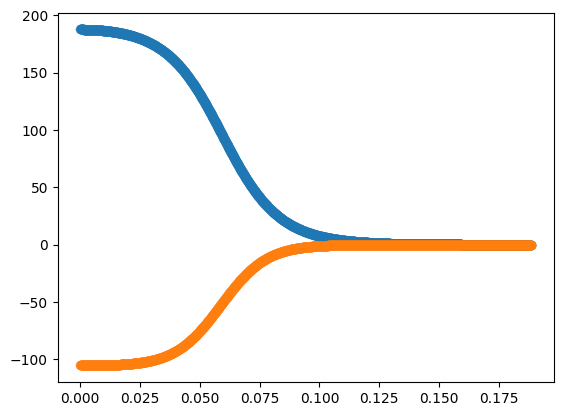

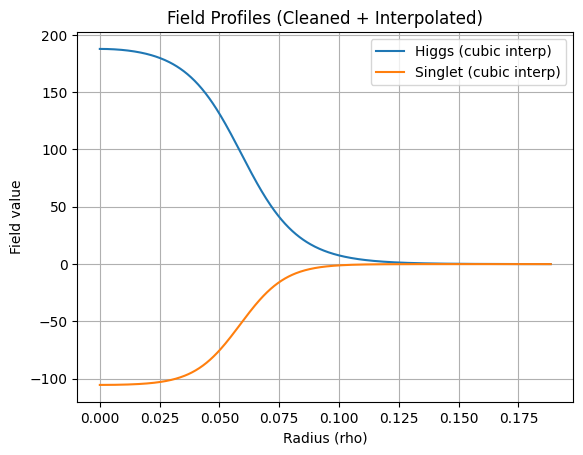

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Load data
data = np.loadtxt("field_profiles.txt", comments='#')

rho_bp = data[:, 1]
h_bp   = data[:, 2]
s_bp   = data[:, 3]


# Interpolators
h_interp = interp1d(rho_bp, h_bp, kind='cubic',
                   fill_value=(h_bp[0], h_bp[-1]), bounds_error=False)

s_interp = interp1d(rho_bp, s_bp, kind='cubic',
                   fill_value=(s_bp[0], s_bp[-1]), bounds_error=False)

# Smooth grid for plotting interpolation
rho_fine = np.linspace(rho_bp[0], rho_bp[-1], 500)

# Plot
plt.figure()

# Raw data
plt.plot(rho_bp, h_bp, 'o', label="Higgs (raw)", alpha=0.6)
plt.plot(rho_bp, s_bp, 'o', label="Singlet (raw)", alpha=0.6)

plt.figure()
# Interpolated curves
plt.plot(rho_fine, h_interp(rho_fine), '-', label="Higgs (cubic interp)")
plt.plot(rho_fine, s_interp(rho_fine), '-', label="Singlet (cubic interp)")

plt.xlabel("Radius (rho)")
plt.ylabel("Field value")
plt.title("Field Profiles (Cleaned + Interpolated)")
plt.legend()
plt.grid()

plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
import sys

data = np.loadtxt("field_profiles.txt", comments='#')

rho_profile = data[:, 1]   # radius
x_profile = data[:, 2]   # scalar field x
y_profile = data[:, 3]   # scalar field y


# Interpolation function
h_interp = interp1d(rho_profile,x_profile, kind='cubic',fill_value=(x_profile[0], x_profile[-1]), bounds_error=False)

s_interp = interp1d(rho_profile,
  y_profile,
   kind='cubic',
    fill_value=(y_profile[0], y_profile[-1]),
    bounds_error=False
)

def phi_int_step(r):
    return h_interp(r), s_interp(r)
  

# ==================================================
# POTENTIAL DERIVATIVES
# ==================================================
def veff( h, s, T):
    """
    SM + Singlet effective potential at finite T
    V = (m_h^2/2)h^2 + (m_s^2/2)s^2 + lambda_h h^4 + lambda_s/4 s^4 + lambda_m/4 h^2 s^2
    where m_h^2 = -2 c_h (T^2 - Tc^2) etc
    """
    # Temperature-dependent masses (simplified)
    m_h_sq = 2.0 * lambda_h * (vEW*vEW - (c_h/lambda_h)*T*T)
    m_s_sq = - lambda_s * (vEW*vEW - (c_h/lambda_h)*Tc*Tc) *(lambda_h*lambda_s)**(0.5) -c_s *Tc  # placeholder
    
    return (-0.5 * m_h_sq * h*h + 
            0.5 * m_s_sq * s*s + 
            0.25*lambda_h * h*h*h*h + 
            0.25 * lambda_s * s*s*s*s + 
            0.25 * lambda_m * h*h * s*s)

def dV_dh(h, s, T):
   """dV/dh for SM+Singlet at temperature T"""
   m_h_T_sq = 2 * lambda_h * (vEW**2 - c_h*T**2)
   m_s_T_sq = 1000  # placeholder
   return - m_h_T_sq * h + lambda_h*h**3 + 0.5*lambda_m*h*s**2

def dV_ds(h, s, T):
   """dV/ds for SM+Singlet at temperature T"""

   m_s_sq =- lambda_s * (vEW*vEW - (c_h/lambda_h)*Tc*Tc) *(lambda_h*lambda_s)**(0.5) -c_s *Tc  # placeholder
    
   return m_s_sq * s + lambda_s * s*s*s + 0.5 * lambda_m * h*h * s

def dVdT(h, s, T) :
    """
    dV/dT = -c_h h^2 - c_s s^2 (thermal correction derivative)
    """
    return c_h * h*h *T

# Compute forces
#dVdh = dV_dh(h_field, s_field, T)
#dVds = dV_ds(h_field, s_field, T)

# ==================================================
# FLUID SETUP (simplified bag model)
# ==================================================

vEW = 246.22
To = 100/np.sqrt(2)
Tn = 82  # Slightly higher for expansion
Tc = 100

# Model parameters (tune to match your potential)
lambda_m = 1.5
lambda_s = 0.65

a = 35.0  # radiation constant

def w_enthalpy(h,s,T):
   return (4.0/3.0) * a * T**4 - T * dVdT(h, s, T)


def p_pressure(T, h, s):
   # Bag model: p = aT^4/3 - epsilon (bag constant)
   # epsilon ~ Veff at minimum
   return (1.0/3.0) * a * T**4  -veff(h,s,T)# placeholder bag constant


In [7]:
# set the initial conditions for fluid and the grid size
N = 10000
rmax = 0.25 #40 percent larger than the domain to allow for expansion
rs = np.zeros(N)
ws = np.ones(N)
vs = np.zeros(N)
vw = 0.95
# ps = np.ones(N)
dx = rmax / (N-1)
a = 35.0 #11.267798357910351#35.119
eta = 0.3*Tc#0.5*Tc
# cfl = dx**2
# vw = 0.8
k = 0


for i in range(N):
    r = rmax / N * i + rmax / N / 2
    rs[i] = r
    # ws[i] = w_enthalpy(Tn, phi_int(r), a)
    # ps[i] = p_pressure(Tn, phi_int(r), a)

# phis = phi_int(rs) 
h, s = phi_int_step(rs)  
wn = w_enthalpy(h, s, Tn)
# wn = w_enthalpy(Tn, np.zeros_like(phis), a)
w_abs = wn.copy()

vs = np.clip(vs, -0.995, 0.995)
gammas = 1.0 / np.sqrt(1.0 - vs**2)
        
ps = p_pressure(Tn, h, s) 
# ps = p_pressure(Tn, np.zeros_like(phis), a)
u1 = h
u2 = np.zeros(N)
u3 = s
u4 = np.zeros(N)
# u2 = np.ones(N)*1000
u5 = w_abs * gammas**2 - ps
u6 = w_abs * gammas**2 * vs

print(np.min(u1), np.max(u1))
print(np.min(u5), np.max(u5))
print(np.min(ps), np.max(ps))


6.84681624e-12 187.73791373832364
1478261640.1864307 1582426160.0
512807042.4084896 571424975.4381104


In [8]:
fd = scalarAfluid1d_toy( rs, u1, u2, u3, u4, u5, u6, 1.6, 0.1, w_abs, vs, wn, h, s,
                  lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a, To, Tc, eta,vw, n_iter=40)


INIT: u1 range: [6.846816e-12, 1.877379e+02]
INIT: u5 range: [1.478262e+09, 1.582426e+09]
INIT: w range: [2.000310e+09, 2.109902e+09]
INIT: p range: [4.297048e+08, 5.424733e+08]
INIT: T range: [8.200000e+01, 8.200000e+01]


In [10]:
from tqdm.notebook import tqdm
import time

# run the simulation
tmax = 6
n_steps = 30000


w_list = []
v_list = []
phi_list = []
dphidt_list = []
phi_list2 = []
dphidt_list2 = []

start_time = time.time()

# Add tqdm here for progress bar with time remaining
for step in tqdm(range(n_steps), desc="Simulating", unit="step"):
    dt = fd.dt
    fd.advance_rk4(dt)
 
    
    if step % 10 == 0:
        w_list.append(fd.w.copy())
        v_list.append(fd.v.copy())
        phi_list.append(fd.u1.copy())
        dphidt_list.append(fd.u2.copy())
        phi_list2.append(fd.u3.copy())
        dphidt_list2.append(fd.u4.copy())

elapsed = time.time() - start_time
print(f"Simulation completed in {elapsed:.2f} seconds")

w_list = np.array(w_list)
v_list = np.array(v_list)
#t_list = np.arange(0, tmax, dt)
t_list = np.arange(0, len(w_list) * 10 * dt, 10 * dt)  # Correct time array based on actual stored steps
x_list = rs

Simulating:   0%|          | 0/30000 [00:00<?, ?step/s]

Simulation completed in 1094.43 seconds


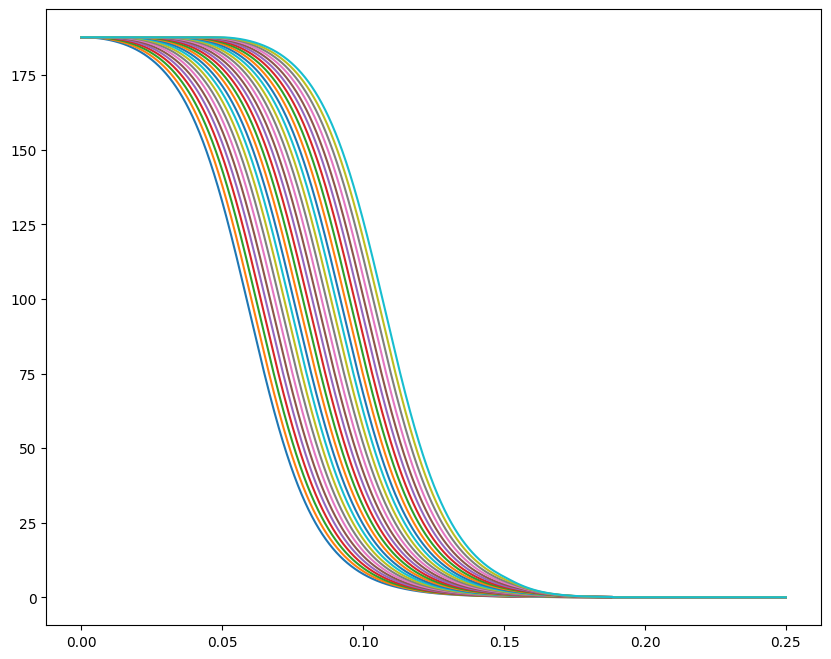

In [16]:
#a =11
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(phi_list)):
    if(v_idx % 100 == 0):
        plt.plot(rs, phi_list[v_idx])

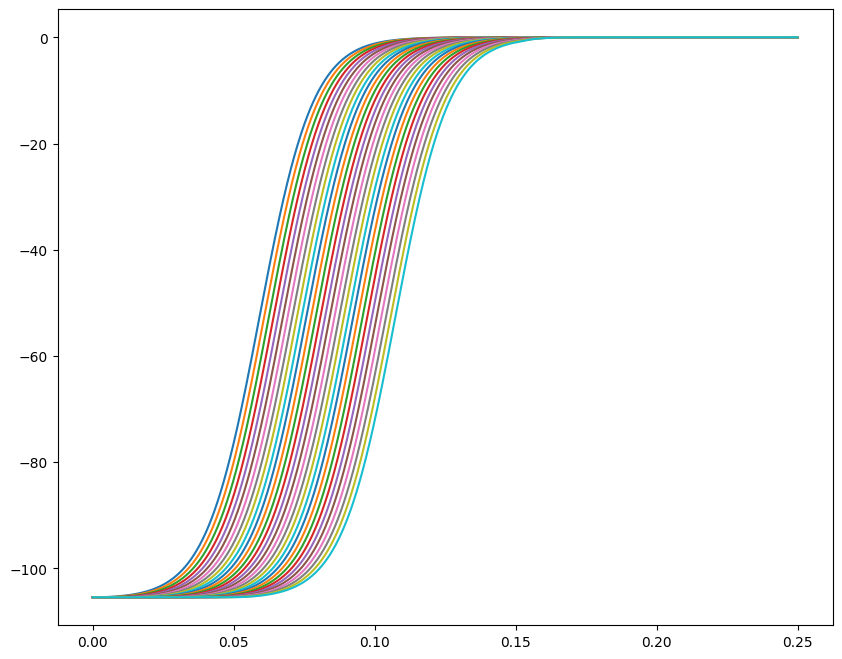

In [17]:
#a =11
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(phi_list2)):
    if(v_idx % 100 == 0):
        plt.plot(rs, phi_list2[v_idx])

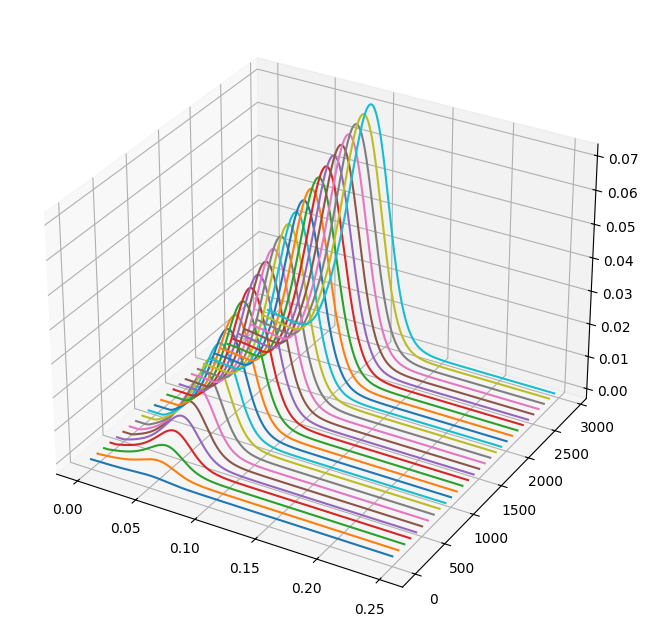

In [18]:
#a =11
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for v_idx in range(len(v_list)):
    if(v_idx % 100 == 0):
        ax.plot(rs, [v_idx]*len(rs), v_list[v_idx])

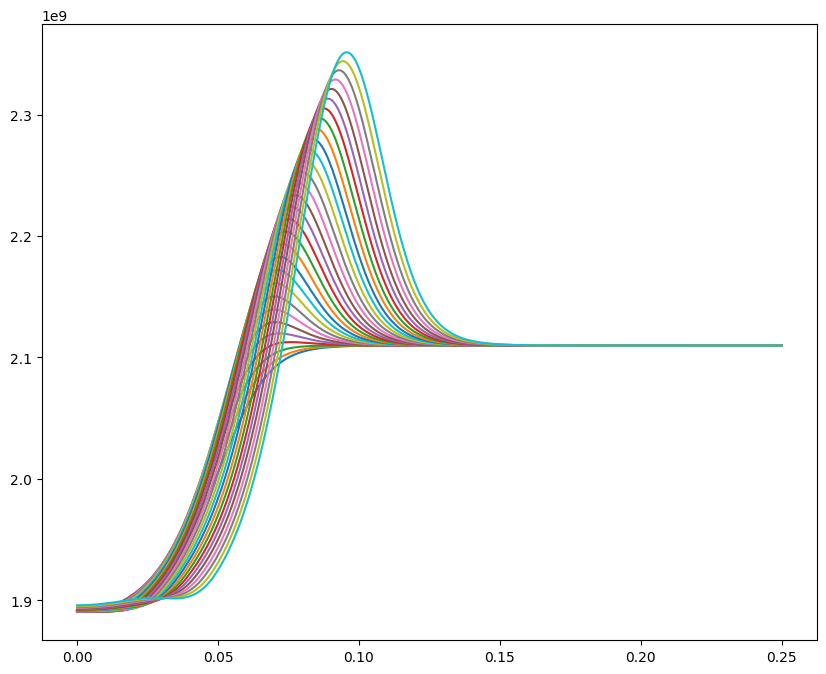

In [19]:
#a =11
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(w_list)):
    if(v_idx % 100 == 0):
        plt.plot(rs, w_list[v_idx])

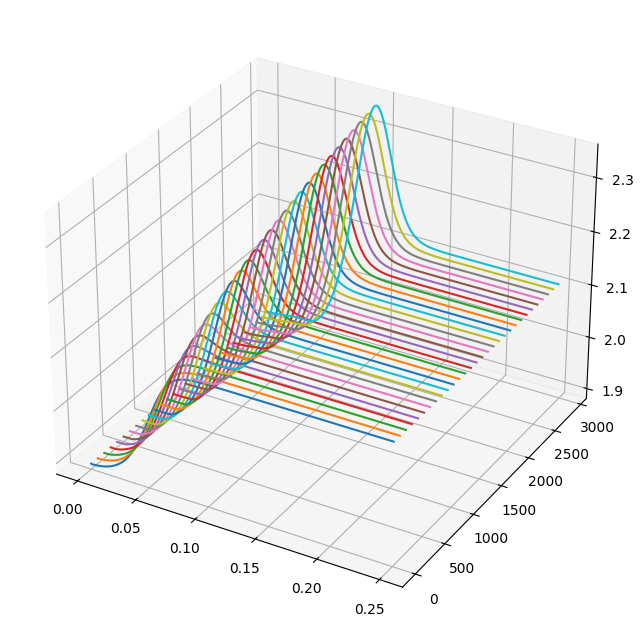

In [15]:
#a =11
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for v_idx in range(len(w_list)):
    if(v_idx % 100 == 0):
        ax.plot(rs, [v_idx]*len(rs), w_list[v_idx])

In [14]:
# set the initial conditions for fluid and the grid size
N = 10000
rmax = 0.25 #40 percent larger than the domain to allow for expansion
rs = np.zeros(N)
ws = np.ones(N)
vs = np.zeros(N)
vw = 0.4
# ps = np.ones(N)
dx = rmax / (N-1)
a = 35.0 #11.267798357910351#35.119
eta = 0.3*Tc#0.5*Tc
# cfl = dx**2
# vw = 0.8
k = 0


for i in range(N):
    r = rmax / N * i + rmax / N / 2
    rs[i] = r
    # ws[i] = w_enthalpy(Tn, phi_int(r), a)
    # ps[i] = p_pressure(Tn, phi_int(r), a)

# phis = phi_int(rs) 
h, s = phi_int_step(rs)  
wn = w_enthalpy(h, s, Tn)
# wn = w_enthalpy(Tn, np.zeros_like(phis), a)
w_abs = wn.copy()

vs = np.clip(vs, -0.995, 0.995)
gammas = 1.0 / np.sqrt(1.0 - vs**2)
        
ps = p_pressure(Tn, h, s) 
# ps = p_pressure(Tn, np.zeros_like(phis), a)
u1 = h
u2 = np.zeros(N)
u3 = s
u4 = np.zeros(N)
# u2 = np.ones(N)*1000
u5 = w_abs * gammas**2 - ps
u6 = w_abs * gammas**2 * vs

print(np.min(u1), np.max(u1))
print(np.min(u5), np.max(u5))
print(np.min(ps), np.max(ps))

fd = scalarAfluid1d_toy( rs, u1, u2, u3, u4, u5, u6, 1.6, 0.1, w_abs, vs, wn, h, s,
                  lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a, To, Tc, eta,vw, n_iter=40)

from tqdm.notebook import tqdm
import time

# run the simulation
tmax = 6
n_steps = 30000


w_list = []
v_list = []
phi_list = []
dphidt_list = []
phi_list2 = []
dphidt_list2 = []

start_time = time.time()

# Add tqdm here for progress bar with time remaining
for step in tqdm(range(n_steps), desc="Simulating", unit="step"):
    dt = fd.dt
    fd.advance_rk4(dt)
 
    
    if step % 10 == 0:
        w_list.append(fd.w.copy())
        v_list.append(fd.v.copy())
        phi_list.append(fd.u1.copy())
        dphidt_list.append(fd.u2.copy())
        phi_list2.append(fd.u3.copy())
        dphidt_list2.append(fd.u4.copy())

elapsed = time.time() - start_time
print(f"Simulation completed in {elapsed:.2f} seconds")

w_list = np.array(w_list)
v_list = np.array(v_list)
t_list = np.arange(0, tmax, dt)
#t_list = np.arange(0, len(w_list) * 10 * dt, 10 * dt)  # Correct time array based on actual stored steps
x_list = rs



6.84681624e-12 187.73791373832364
1478261640.1864307 1582426160.0
512807042.4084896 571424975.4381104
INIT: u1 range: [6.846816e-12, 1.877379e+02]
INIT: u5 range: [1.478262e+09, 1.582426e+09]
INIT: w range: [2.000310e+09, 2.109902e+09]
INIT: p range: [4.297048e+08, 5.424733e+08]
INIT: T range: [8.200000e+01, 8.200000e+01]


Simulating:   0%|          | 0/30000 [00:00<?, ?step/s]

KeyboardInterrupt: 

In [ ]:
 #vw = 0.4
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(phi_list)):
    if(v_idx % 100 == 0):
        plt.plot(rs, phi_list[v_idx])

In [ ]:
#vw = 0.4
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(phi_list2)):
    if(v_idx % 100 == 0):
        plt.plot(rs, phi_list2[v_idx])

In [ ]:
#vw = 0.4
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(v_list)):
    if(v_idx % 100 == 0):
        plt.plot(rs, v_list[v_idx])

In [ ]:
#vw = 0.4
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(w_list)):
    if(v_idx % 100 == 0):
        plt.plot(rs, w_list[v_idx])

In [ ]:
# set the initial conditions for fluid and the grid size
N = 10000
rmax = 0.25 #40 percent larger than the domain to allow for expansion
rs = np.zeros(N)
ws = np.ones(N)
vs = np.zeros(N)
vw = 1
# ps = np.ones(N)
dx = rmax / (N-1)
a = 35.0 #11.267798357910351#35.119
eta = 0.3*Tc#0.5*Tc
# cfl = dx**2
# vw = 0.8
k = 0


for i in range(N):
    r = rmax / N * i + rmax / N / 2
    rs[i] = r
    # ws[i] = w_enthalpy(Tn, phi_int(r), a)
    # ps[i] = p_pressure(Tn, phi_int(r), a)

# phis = phi_int(rs) 
h, s = phi_int_step(rs)  
wn = w_enthalpy(h, s, Tn)
# wn = w_enthalpy(Tn, np.zeros_like(phis), a)
w_abs = wn.copy()

vs = np.clip(vs, -0.995, 0.995)
gammas = 1.0 / np.sqrt(1.0 - vs**2)
        
ps = p_pressure(Tn, h, s) 
# ps = p_pressure(Tn, np.zeros_like(phis), a)
u1 = h
u2 = np.zeros(N)
u3 = s
u4 = np.zeros(N)
# u2 = np.ones(N)*1000
u5 = w_abs * gammas**2 - ps
u6 = w_abs * gammas**2 * vs

print(np.min(u1), np.max(u1))
print(np.min(u5), np.max(u5))
print(np.min(ps), np.max(ps))

fd = scalarAfluid1d_toy( rs, u1, u2, u3, u4, u5, u6, 1.6, 0.1, w_abs, vs, wn, h, s,
                  lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a, To, Tc, eta,vw, n_iter=40)

from tqdm.notebook import tqdm
import time

# run the simulation
tmax = 6
n_steps = 30000


w_list = []
v_list = []
phi_list = []
dphidt_list = []
phi_list2 = []
dphidt_list2 = []

start_time = time.time()

# Add tqdm here for progress bar with time remaining
for step in tqdm(range(n_steps), desc="Simulating", unit="step"):
    dt = fd.dt
    fd.advance_rk4(dt)
 
    
    if step % 10 == 0:
        w_list.append(fd.w.copy())
        v_list.append(fd.v.copy())
        phi_list.append(fd.u1.copy())
        dphidt_list.append(fd.u2.copy())
        phi_list2.append(fd.u3.copy())
        dphidt_list2.append(fd.u4.copy())

elapsed = time.time() - start_time
print(f"Simulation completed in {elapsed:.2f} seconds")

w_list = np.array(w_list)
v_list = np.array(v_list)
t_list = np.arange(0, tmax, dt)
#t_list = np.arange(0, len(w_list) * 10 * dt, 10 * dt)  # Correct time array based on actual stored steps
x_list = rs



In [ ]:
#vw = 1
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(phi_list)):
    if(v_idx % 100 == 0):
        plt.plot(rs, phi_list[v_idx])

In [ ]:
#vw = 1
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(phi_list2)):
    if(v_idx % 100 == 0):
        plt.plot(rs, phi_list2[v_idx])

In [ ]:
#vw = 1
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(w_list)):
    if(v_idx % 100 == 0):
        plt.plot(rs, w_list[v_idx])

In [ ]:
#vw = 1
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(v_list)):
    if(v_idx % 100 == 0):
        plt.plot(rs, v_list[v_idx])

In [ ]:
# set the initial conditions for fluid and the grid size
N = 10000
rmax = 0.25 #40 percent larger than the domain to allow for expansion
rs = np.zeros(N)
ws = np.ones(N)
vs = np.zeros(N)
vw = 1.3
# ps = np.ones(N)
dx = rmax / (N-1)
a = 35.0 #11.267798357910351#35.119
eta = 0.3*Tc#0.5*Tc
# cfl = dx**2
# vw = 0.8
k = 0


for i in range(N):
    r = rmax / N * i + rmax / N / 2
    rs[i] = r
    # ws[i] = w_enthalpy(Tn, phi_int(r), a)
    # ps[i] = p_pressure(Tn, phi_int(r), a)

# phis = phi_int(rs) 
h, s = phi_int_step(rs)  
wn = w_enthalpy(h, s, Tn)
# wn = w_enthalpy(Tn, np.zeros_like(phis), a)
w_abs = wn.copy()

vs = np.clip(vs, -0.995, 0.995)
gammas = 1.0 / np.sqrt(1.0 - vs**2)
        
ps = p_pressure(Tn, h, s) 
# ps = p_pressure(Tn, np.zeros_like(phis), a)
u1 = h
u2 = np.zeros(N)
u3 = s
u4 = np.zeros(N)
# u2 = np.ones(N)*1000
u5 = w_abs * gammas**2 - ps
u6 = w_abs * gammas**2 * vs

print(np.min(u1), np.max(u1))
print(np.min(u5), np.max(u5))
print(np.min(ps), np.max(ps))

fd = scalarAfluid1d_toy( rs, u1, u2, u3, u4, u5, u6, 1.6, 0.1, w_abs, vs, wn, h, s,
                  lambda_h, lambda_s,  lambda_m,c_h,  c_s,  vEW,a, To, Tc, eta,vw, n_iter=40)

from tqdm.notebook import tqdm
import time

# run the simulation
tmax = 6
n_steps = 30000


w_list = []
v_list = []
phi_list = []
dphidt_list = []
phi_list2 = []
dphidt_list2 = []

start_time = time.time()

# Add tqdm here for progress bar with time remaining
for step in tqdm(range(n_steps), desc="Simulating", unit="step"):
    dt = fd.dt
    fd.advance_rk4(dt)
 
    
    if step % 10 == 0:
        w_list.append(fd.w.copy())
        v_list.append(fd.v.copy())
        phi_list.append(fd.u1.copy())
        dphidt_list.append(fd.u2.copy())
        phi_list2.append(fd.u3.copy())
        dphidt_list2.append(fd.u4.copy())

elapsed = time.time() - start_time
print(f"Simulation completed in {elapsed:.2f} seconds")

w_list = np.array(w_list)
v_list = np.array(v_list)
t_list = np.arange(0, tmax, dt)
#t_list = np.arange(0, len(w_list) * 10 * dt, 10 * dt)  # Correct time array based on actual stored steps
x_list = rs



In [ ]:
#vw = 1.3
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(phi_list)):
    if(v_idx % 100 == 0):
        plt.plot(rs, phi_list[v_idx])

In [ ]:
#vw = 1.3
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(phi_list2)):
    if(v_idx % 100 == 0):
        plt.plot(rs, phi_list2[v_idx])

In [ ]:
#vw = 1.3
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(v_list)):
    if(v_idx % 100 == 0):
        plt.plot(rs, v_list[v_idx])

In [ ]:
#vw = 1.3
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

for v_idx in range(len(w_list)):
    if(v_idx % 100 == 0):
        plt.plot(rs, w_list[v_idx])